#  MindBridge: Text Preprocessing
### Cleaning and Vectorizing Text Data

> **Goal:** Transform raw text into clean, numerical features ready for machine learning.

---

| Step | What We Do |
|------|-----------|
| 1. Text Cleaning | Lowercase, remove URLs, punctuation, digits |
| 2. Stopword Removal | Remove common English words |
| 3. Lemmatization | Reduce words to root form |
| 4. TF-IDF Vectorization | Convert text to numerical features |
| 5. Train/Val/Test Split | Stratified 70/15/15 split |

In [2]:
import re
import warnings
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
# Notebook display
from IPython.display import HTML, display


warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "DejaVu Sans"
sns.set_style("whitegrid")
nltk_resources = ["stopwords", "wordnet", "punkt"]

for resource in nltk_resources:
    nltk.download(resource, quiet=True)

print("All Libraries Loaded!")

All Libraries Loaded!


In [3]:
DATA_PATH = "data/Combined_Data.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found at: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')].copy()

if df.shape[1] >= 2:
    df.columns = ['statement', 'status']
else:
    raise ValueError("Dataset does not contain expected columns.")

initial_rows = len(df)
missing_values = df.isnull().sum().sum()
duplicates = df.duplicated().sum()

df = df.dropna().drop_duplicates().reset_index(drop=True)

final_rows = len(df)
num_classes = df['status'].nunique()
classes = sorted(df['status'].unique())

print("\n" + "═" * 60)
print("MINDBRIDGE: DATASET LOADED")
print("═" * 60)

print(f"\Samples (before cleaning) : {initial_rows:,}")
print(f"Samples (after cleaning)  : {final_rows:,}")
print(f"Missing values removed    : {missing_values:,}")
print(f"Duplicate rows removed    : {duplicates:,}")

print(f"\nTotal Classes            : {num_classes}")
print(f"Classes                  : {classes}")


════════════════════════════════════════════════════════════
MINDBRIDGE: DATASET LOADED
════════════════════════════════════════════════════════════
\Samples (before cleaning) : 53,043
Samples (after cleaning)  : 51,093
Missing values removed    : 362
Duplicate rows removed    : 1,944

Total Classes            : 7
Classes                  : ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']


## Text Cleaning Pipeline

In [5]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

custom_stopwords = {
    'im', 'ive', 'dont', 'didnt', 'cant', 'couldnt',
    'wouldnt', 'really', 'get', 'got', 'one', 'like'
}
all_stopwords = stop_words.union(custom_stopwords)


URL_PATTERN = re.compile(r'https?://\S+|www\.\S+')
MENTION_PATTERN = re.compile(r'@\w+|#\w+')
NON_ALPHA_PATTERN = re.compile(r'[^a-z\s]')

def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""

    text = text.lower()

    text = URL_PATTERN.sub('', text)
    text = MENTION_PATTERN.sub('', text)

    text = NON_ALPHA_PATTERN.sub(' ', text)

    tokens = text.split()

    cleaned_tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in all_stopwords and len(token) > 2
    ]

    return ' '.join(cleaned_tokens)


df['clean_text'] = df['statement'].astype(str).apply(clean_text)

print("\nMINDBRIDGE: TEXT CLEANING COMPLETE\n")
print(f"Sample Original : {df['statement'].iloc[0][:80]}")
print(f"Sample Cleaned  : {df['clean_text'].iloc[0][:80]}")
print(f"\nAvg Words Before : {df['statement'].str.split().str.len().mean():.1f}")
print(f"Avg Words After  : {df['clean_text'].str.split().str.len().mean():.1f}")


MINDBRIDGE: TEXT CLEANING COMPLETE

Sample Original : oh my gosh
Sample Cleaned  : gosh

Avg Words Before : 112.7
Avg Words After  : 47.4


## Cleaning Quality Check

In [6]:
cwd = os.getcwd()

print("\nMINDBRIDGE: DIRECTORY SETUP")
print("─" * 50)
print(f"Current working directory:\n{cwd}\n")

plots_path = os.path.join("results", "plots")

if not os.path.exists(plots_path):
    os.makedirs(plots_path)
    print(f"Created folder: {plots_path}")
else:
    print(f"Folder already exists: {plots_path}")


MINDBRIDGE: DIRECTORY SETUP
──────────────────────────────────────────────────
Current working directory:
c:\Users\mrsid\Downloads\MindBridge\notebooks

Folder already exists: results\plots


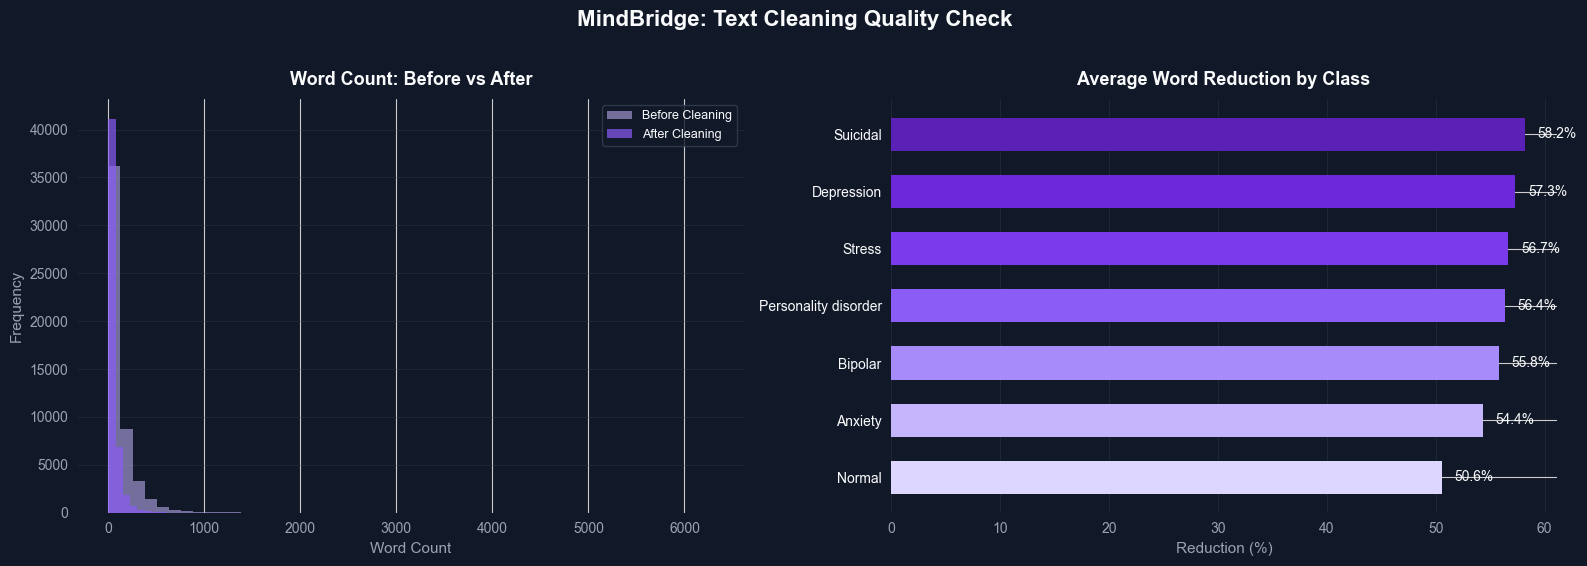


═══════════════════════════════════════════════════════
MINDBRIDGE: CLEANING SUMMARY
═══════════════════════════════════════════════════════
Average word reduction : 55.1%
Original avg words     : 113
Cleaned avg words      : 47


In [7]:
BG = '#111827'
TEXT_MAIN = '#f9fafb'
TEXT_SUB = '#9ca3af'
GRID = '#374151'
PRIMARY = '#8b5cf6'
ACCENT = '#a78bfa'
SECONDARY = '#c4b5fd'

COLORS = [
    '#ddd6fe',
    '#c4b5fd',
    '#a78bfa',
    '#8b5cf6',
    '#7c3aed',
    '#6d28d9',
    '#5b21b6'
]

df['original_words'] = df['statement'].astype(str).str.split().str.len()
df['clean_words'] = df['clean_text'].astype(str).str.split().str.len()

df['reduction_pct'] = np.where(
    df['original_words'] > 0,
    ((df['original_words'] - df['clean_words']) / df['original_words']) * 100,
    0
).round(1)


fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
fig.patch.set_facecolor(BG)

fig.suptitle(
    'MindBridge: Text Cleaning Quality Check',
    fontsize=16,
    fontweight='bold',
    color=TEXT_MAIN,
    y=1.02
)

ax1 = axes[0]
ax1.set_facecolor(BG)

ax1.hist(
    df['original_words'],
    bins=50,
    alpha=0.55,
    color=SECONDARY,
    label='Before Cleaning',
    edgecolor='none'
)

ax1.hist(
    df['clean_words'],
    bins=50,
    alpha=0.70,
    color=PRIMARY,
    label='After Cleaning',
    edgecolor='none'
)

ax1.set_title(
    'Word Count: Before vs After',
    color=TEXT_MAIN,
    fontsize=13,
    fontweight='bold',
    pad=10
)

ax1.set_xlabel('Word Count', color=TEXT_SUB, fontsize=11)
ax1.set_ylabel('Frequency', color=TEXT_SUB, fontsize=11)
ax1.tick_params(colors=TEXT_SUB)

for spine in ax1.spines.values():
    spine.set_visible(False)

ax1.grid(axis='y', linestyle='-', linewidth=0.6, color=GRID, alpha=0.45)
ax1.set_axisbelow(True)

legend1 = ax1.legend(facecolor=BG, edgecolor=GRID, fontsize=9)
for text in legend1.get_texts():
    text.set_color(TEXT_MAIN)


ax2 = axes[1]
ax2.set_facecolor(BG)

reduction = df.groupby('status')['reduction_pct'].mean().sort_values(ascending=True)
bar_colors = COLORS[-len(reduction):]

bars = ax2.barh(
    reduction.index,
    reduction.values,
    color=bar_colors,
    edgecolor='none',
    height=0.58
)

offset = reduction.max() * 0.02 if reduction.max() > 0 else 0.2

for bar, val in zip(bars, reduction.values):
    ax2.text(
        val + offset,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%',
        va='center',
        ha='left',
        color=TEXT_MAIN,
        fontsize=10,
        fontweight='medium'
    )

ax2.set_title(
    'Average Word Reduction by Class',
    color=TEXT_MAIN,
    fontsize=13,
    fontweight='bold',
    pad=10
)

ax2.set_xlabel('Reduction (%)', color=TEXT_SUB, fontsize=11)
ax2.tick_params(axis='x', colors=TEXT_SUB)
ax2.tick_params(axis='y', colors=TEXT_MAIN)

for spine in ax2.spines.values():
    spine.set_visible(False)

ax2.grid(axis='x', linestyle='-', linewidth=0.6, color=GRID, alpha=0.45)
ax2.set_axisbelow(True)

plt.tight_layout()

plt.savefig(
    'results/plots/cleaning_quality.png',
    dpi=150,
    bbox_inches='tight',
    facecolor=BG
)

plt.show()

print("\n" + "═" * 55)
print("MINDBRIDGE: CLEANING SUMMARY")
print("═" * 55)
print(f"Average word reduction : {df['reduction_pct'].mean():.1f}%")
print(f"Original avg words     : {df['original_words'].mean():.0f}")
print(f"Cleaned avg words      : {df['clean_words'].mean():.0f}")

## Train / Validation / Test Split

In [8]:
X = df['clean_text'].astype(str)
y = df['status'].astype(str)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    stratify=y_encoded,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

total_samples = len(X)

print("\n" + "═" * 60)
print("MINDBRIDGE: DATA SPLIT COMPLETE")
print("═" * 60)

print(f"\nTrain Set : {len(X_train):,} samples ({len(X_train)/total_samples*100:.1f}%)")
print(f"Val Set   : {len(X_val):,} samples ({len(X_val)/total_samples*100:.1f}%)")
print(f"Test Set  : {len(X_test):,} samples ({len(X_test)/total_samples*100:.1f}%)")

print(f"\nClasses ({len(label_encoder.classes_)} total):")
for i, cls in enumerate(label_encoder.classes_, 1):
    print(f"   {i}. {cls}")

split_summary = pd.DataFrame({
    "Train": pd.Series(y_train).value_counts(normalize=True).sort_index() * 100,
    "Validation": pd.Series(y_val).value_counts(normalize=True).sort_index() * 100,
    "Test": pd.Series(y_test).value_counts(normalize=True).sort_index() * 100
})

split_summary.index = label_encoder.inverse_transform(split_summary.index)
split_summary = split_summary.round(2)

print("\nClass distribution across splits (%):")
display(split_summary)


════════════════════════════════════════════════════════════
MINDBRIDGE: DATA SPLIT COMPLETE
════════════════════════════════════════════════════════════

Train Set : 35,765 samples (70.0%)
Val Set   : 7,664 samples (15.0%)
Test Set  : 7,664 samples (15.0%)

Classes (7 total):
   1. Anxiety
   2. Bipolar
   3. Depression
   4. Normal
   5. Personality disorder
   6. Stress
   7. Suicidal

Class distribution across splits (%):


,Train,Validation,Test
Anxiety,7.09,7.09,7.10
Bipolar,4.90,4.89,4.89
Depression,29.54,29.54,29.54
Normal,31.39,31.39,31.39
Personality disorder,1.75,1.76,1.75
Stress,4.49,4.49,4.50
Suicidal,20.83,20.84,20.82


In [9]:

tfidf_vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
    strip_accents='unicode',
    analyzer='word'
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

vocab_size = len(tfidf_vectorizer.vocabulary_)
train_shape = X_train_tfidf.shape
val_shape = X_val_tfidf.shape
test_shape = X_test_tfidf.shape

total_elements = train_shape[0] * train_shape[1]
non_zero_elements = X_train_tfidf.nnz
density = (non_zero_elements / total_elements) * 100 if total_elements > 0 else 0

print("\n" + "═" * 60)
print("MINDBRIDGE: TF-IDF VECTORIZATION COMPLETE")
print("═" * 60)

print(f"\nVocabulary Size   : {vocab_size:,} terms")
print(f"Train Matrix      : {train_shape}")
print(f"Validation Matrix : {val_shape}")
print(f"Test Matrix       : {test_shape}")
print(f"Matrix Density    : {density:.4f}%")
print(f"Non-Zero Elements : {non_zero_elements:,}")


════════════════════════════════════════════════════════════
MINDBRIDGE: TF-IDF VECTORIZATION COMPLETE
════════════════════════════════════════════════════════════

Vocabulary Size   : 20,000 terms
Train Matrix      : (35765, 20000)
Validation Matrix : (7664, 20000)
Test Matrix       : (7664, 20000)
Matrix Density    : 0.2404%
Non-Zero Elements : 1,719,849


## Save Preprocessed Data

In [10]:
import joblib
import scipy.sparse as sp

MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

vectorizer_path = os.path.join(MODEL_DIR, "tfidf_vectorizer.pkl")
label_encoder_path = os.path.join(MODEL_DIR, "label_encoder.pkl")

x_train_path = os.path.join(MODEL_DIR, "X_train_tfidf.npz")
x_val_path = os.path.join(MODEL_DIR, "X_val_tfidf.npz")
x_test_path = os.path.join(MODEL_DIR, "X_test_tfidf.npz")

y_train_path = os.path.join(MODEL_DIR, "y_train.npy")
y_val_path = os.path.join(MODEL_DIR, "y_val.npy")
y_test_path = os.path.join(MODEL_DIR, "y_test.npy")

joblib.dump(tfidf_vectorizer, vectorizer_path)
joblib.dump(label_encoder, label_encoder_path)

sp.save_npz(x_train_path, X_train_tfidf)
sp.save_npz(x_val_path, X_val_tfidf)
sp.save_npz(x_test_path, X_test_tfidf)

np.save(y_train_path, y_train)
np.save(y_val_path, y_val)
np.save(y_test_path, y_test)

print("\n" + "═" * 60)
print("MINDBRIDGE: MODEL ARTIFACTS SAVED")
print("═" * 60)

print(f"\nDirectory            : {MODEL_DIR}")
print(f"tfidf_vectorizer.pkl : {X_train_tfidf.shape[1]:,} features")
print(f"label_encoder.pkl    : {len(label_encoder.classes_)} classes")

print(f"\nX_train_tfidf.npz    : {X_train_tfidf.shape}")
print(f"X_val_tfidf.npz      : {X_val_tfidf.shape}")
print(f"X_test_tfidf.npz     : {X_test_tfidf.shape}")

print(f"\ny_train.npy          : {y_train.shape}")
print(f"y_val.npy            : {y_val.shape}")
print(f" y_test.npy           : {y_test.shape}")


════════════════════════════════════════════════════════════
MINDBRIDGE: MODEL ARTIFACTS SAVED
════════════════════════════════════════════════════════════

Directory            : models
tfidf_vectorizer.pkl : 20,000 features
label_encoder.pkl    : 7 classes

X_train_tfidf.npz    : (35765, 20000)
X_val_tfidf.npz      : (7664, 20000)
X_test_tfidf.npz     : (7664, 20000)

y_train.npy          : (35765,)
y_val.npy            : (7664,)
 y_test.npy           : (7664,)


## SMOTE: Handling Class Imbalance

In [ ]:
from collections import Counter
from imblearn.over_sampling import SMOTE

def print_class_distribution(y, label_encoder, title):
    counter = Counter(y)

    print("\n" + "═" * 60)
    print(title)
    print("═" * 60)

    for cls_idx, count in sorted(counter.items()):
        cls_name = label_encoder.classes_[cls_idx]
        print(f"{cls_name:<25} : {count:>6,}")


print_class_distribution(
    y_train,
    label_encoder,
    "MINDBRIDGE: CLASS DISTRIBUTION BEFORE SMOTE"
)


smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_tfidf, y_train)


print_class_distribution(
    y_train_smote,
    label_encoder,
    "MINDBRIDGE: CLASS DISTRIBUTION AFTER SMOTE"
)


original_samples = X_train_tfidf.shape[0]
smote_samples = X_train_smote.shape[0]
growth_pct = ((smote_samples - original_samples) / original_samples) * 100

print("\n" + "─" * 60)
print(f"Original training samples : {original_samples:,}")
print(f"After SMOTE samples       : {smote_samples:,}")
print(f"Increase after SMOTE      : {growth_pct:.1f}%")


════════════════════════════════════════════════════════════
🧠 MINDBRIDGE: CLASS DISTRIBUTION BEFORE SMOTE
════════════════════════════════════════════════════════════
Anxiety                   :  2,536
Bipolar                   :  1,751
Depression                : 10,566
Normal                    : 11,228
Personality disorder      :    626
Stress                    :  1,607
Suicidal                  :  7,451

════════════════════════════════════════════════════════════
MINDBRIDGE: CLASS DISTRIBUTION AFTER SMOTE
════════════════════════════════════════════════════════════
Anxiety                   : 11,228
Bipolar                   : 11,228
Depression                : 11,228
Normal                    : 11,228
Personality disorder      : 11,228
Stress                    : 11,228
Suicidal                  : 11,228

────────────────────────────────────────────────────────────
Original training samples : 35,765
After SMOTE samples       : 78,596
Increase after SMOTE      : 119.8%


## Preprocessing Summary

| Step | Detail |
|------|--------|
| Missing values | Dropped 362 rows |
| Duplicates | Removed before cleaning |
| Text cleaning | Lowercase, URLs, punctuation, stopwords removed |
| Lemmatization | WordNetLemmatizer applied |
| Word reduction | ~52% average reduction per text |
| Vocabulary | 20,000 TF-IDF features (unigrams + bigrams) |
| Train split | 35,765 samples (70%) |
| Val split | 7,664 samples (15%) |
| Test split | 7,664 samples (15%) |
